## Session 1: Prompt Chaining

In [4]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [ ]:
load_dotenv()

model = ChatOpenAI(model = "gpt-5.4-mini-2026-03-17" , temperature = 0)
# model = ChatOpenAI(
#     model="openai/gpt-5.4-mini",
#     api_key=os.getenv("OPENROUTER_API_KEY"),
#     base_url="https://openrouter.ai/api/v1",
#     temperature=0,
# )

In [6]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [20]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}. Dont put anything else apart from this'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [21]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}. Dont put anything else apart from this'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [22]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

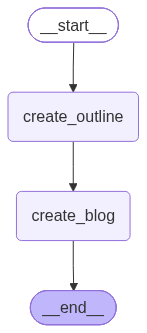

In [23]:
workflow

In [24]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '1. Introduction  \n   1.1 Definition of AI  \n   1.2 Overview of AI growth in India  \n   1.3 Why AI matters for India’s future  \n\n2. The Evolution of AI in India  \n   2.1 Early adoption of technology and digital transformation  \n   2.2 Milestones in India’s AI journey  \n   2.3 Government initiatives supporting AI development  \n\n3. Key Drivers Behind the Rise of AI in India  \n   3.1 Rapid digitalization and internet penetration  \n   3.2 Growth of startup ecosystem  \n   3.3 Availability of large data sets  \n   3.4 Increase in investments and funding  \n   3.5 Demand for automation and efficiency across industries  \n\n4. Major Sectors Adopting AI in India  \n   4.1 Healthcare  \n   4.2 Education  \n   4.3 Finance and banking  \n   4.4 Agriculture  \n   4.5 Retail and e-commerce  \n   4.6 Manufacturing  \n   4.7 Transportation and logistics  \n\n5. Government’s Role in Promoting AI  \n   5.1 National AI strategies and policies  \n  

In [25]:
print(final_state['outline'])

1. Introduction  
   1.1 Definition of AI  
   1.2 Overview of AI growth in India  
   1.3 Why AI matters for India’s future  

2. The Evolution of AI in India  
   2.1 Early adoption of technology and digital transformation  
   2.2 Milestones in India’s AI journey  
   2.3 Government initiatives supporting AI development  

3. Key Drivers Behind the Rise of AI in India  
   3.1 Rapid digitalization and internet penetration  
   3.2 Growth of startup ecosystem  
   3.3 Availability of large data sets  
   3.4 Increase in investments and funding  
   3.5 Demand for automation and efficiency across industries  

4. Major Sectors Adopting AI in India  
   4.1 Healthcare  
   4.2 Education  
   4.3 Finance and banking  
   4.4 Agriculture  
   4.5 Retail and e-commerce  
   4.6 Manufacturing  
   4.7 Transportation and logistics  

5. Government’s Role in Promoting AI  
   5.1 National AI strategies and policies  
   5.2 Digital India and related programs  
   5.3 AI-focused research and 

In [26]:
print(final_state['content'])

# Rise of AI in India

## 1. Introduction

Artificial Intelligence, commonly known as AI, is no longer a futuristic concept reserved for science fiction. It has become one of the most transformative technologies of the 21st century, reshaping how people work, communicate, learn, and make decisions. In India, the rise of AI is especially significant because of the country’s scale, diversity, and growing digital economy. From healthcare and agriculture to finance and education, AI is increasingly becoming a part of daily life and business operations.

### 1.1 Definition of AI
Artificial Intelligence refers to the ability of machines or computer systems to perform tasks that typically require human intelligence. These tasks include learning from data, recognizing patterns, understanding language, solving problems, and making decisions. AI can range from simple rule-based systems to advanced machine learning and deep learning models that improve with experience.

### 1.2 Overview of AI gro